# Intra-center phenotype region query

This tutorial trains the morphology query on molecularly profiled HBC1 and applies it to the independent same-center HBC2 section. PhenoMap and both baselines use HBC2 H&E pixels only during inference; measured Xenium expression, molecular phenotype-related (PR) scores and reference cell annotations are introduced only after inference for evaluation.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError("Please run this notebook from inside the PhenoMap repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from step3.utils.query_evaluation import (
    aggregate_spatial_blocks,
    binary_query_performance,
    load_cell_coordinates,
    orient_molecular_scores_from_source,
    sample_score_maps,
    spatial_block_bootstrap,
    top_fraction_composition,
)
from phenomap import load_tutorial_data
from step3.utils.plotting import (
    plot_binary_query_curves,
    plot_concordance_intervals,
    plot_query_score_map,
    set_plot_style,
)

tutorial_data = load_tutorial_data(repository_root=REPO_ROOT)
OUTPUT_DIR = REPO_ROOT / "outputs" / "05_intra_center_region_query"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TUTORIAL_DIR = REPO_ROOT / "docs" / "source" / "tutorials" / "05_intra_center_region_query"

METHODS = ["PhenoMap", "KEEP", "PathPT"]
METHOD_COLORS = {"PhenoMap": "#D55E5E", "KEEP": "#4C86B7", "PathPT": "#888888"}
CELL_TYPES = [
    "Cancer_epithelial", "Normal_epithelial", "T_cells", "B_cells",
    "Myeloid", "Stromal", "Endothelial", "Unknown",
]
CELL_COLORS = {
    "Cancer_epithelial": "#DE5253", "Normal_epithelial": "#E892CE",
    "T_cells": "#56B356", "B_cells": "#4C92C3", "Myeloid": "#45CBD8",
    "Stromal": "#989898", "Endothelial": "#FF983E", "Unknown": "#333333",
}
DISPLAY_LABELS = {name: name.replace("_", " ") for name in CELL_TYPES}

set_plot_style()
print("PhenoMap intra-center query environment configured.")

PhenoMap intra-center query environment configured.


All source and target resources are resolved by semantic manifest keys. Each expensive result is loaded when present and generated only when a scientifically valid public regeneration path is available.

In [2]:
QUERY_IMAGE = tutorial_data.path("hbc2.he_image")
MAIN_SCORE_PATHS = {
    "PhenoMap": tutorial_data.path("hbc2.phenomap_query_map"),
    "KEEP": tutorial_data.path("hbc2.keep_query_map"),
    "PathPT": tutorial_data.path("hbc2.pathpt_query_map"),
}
CONCORDANCE_SCORE_PATHS = {
    "PhenoMap": tutorial_data.path("hbc2.phenomap_concordance_map"),
    "KEEP": MAIN_SCORE_PATHS["KEEP"],
    "PathPT": MAIN_SCORE_PATHS["PathPT"],
}
ANNOTATION_PATH = tutorial_data.path("hbc2.reference_cell_types")
MASK_PATH = tutorial_data.path("hbc2.nucleus_mask")
COORDINATE_CACHE = tutorial_data.path("hbc2.cell_coordinates")
MOLECULAR_PR_SCORES = tutorial_data.path("hbc2.molecular_pr_scores")
SOURCE_CHECKPOINT = tutorial_data.path("hbc1.source_checkpoint")
STEP3_CONFIG = tutorial_data.path("hbc1.step3_config")


def run_checked(arguments):
    subprocess.run(arguments, cwd=REPO_ROOT, check=True)


def require_final_phenomap_map(key):
    path = tutorial_data.path(key)
    if path.exists():
        return True
    missing_resources = [
        resource_key for resource_key, resource_path in {
            "hbc1.source_checkpoint": SOURCE_CHECKPOINT,
            "hbc1.step3_config": STEP3_CONFIG,
        }.items() if not resource_path.exists()
    ]
    if missing_resources:
        raise FileNotFoundError(
            f"Missing {key}. Regeneration requires both hbc1.source_checkpoint and "
            f"hbc1.step3_config. Configure missing resources: {', '.join(missing_resources)}. "
            "A toy or default configuration is not used."
        )
    raise FileNotFoundError(
        f"Missing {key}. Generate it with hbc1.source_checkpoint and the final "
        "paper-compatible hbc1.step3_config, then set this semantic key in the manifest."
    )


def ensure_baseline(method):
    output_path = MAIN_SCORE_PATHS[method]
    if output_path.exists():
        return True
    arguments = [
        sys.executable, "-m", "step3.baselines.query", "--mode", method.lower(),
        "--query-image", str(tutorial_data.require("hbc2.he_image")),
        "--output", str(output_path),
        "--device", os.environ.get("PHENOMAP_DEVICE", "cuda:0"),
    ]
    if method == "PathPT":
        arguments.extend([
            "--support-image", str(tutorial_data.require("hbc1.pathpt_support_image")),
            "--support-mask", str(tutorial_data.require("hbc1.pathpt_support_mask")),
        ])
    output_path.parent.mkdir(parents=True, exist_ok=True)
    run_checked(arguments)
    if not output_path.exists():
        raise RuntimeError(f"{method} inference completed without producing its configured query map.")
    return False


cache_status = {
    "PhenoMap HBC2 query": require_final_phenomap_map("hbc2.phenomap_query_map"),
    "KEEP zero-shot query": ensure_baseline("KEEP"),
    "PathPT HBC1 prompt-tuned query": ensure_baseline("PathPT"),
    "PhenoMap concordance query": require_final_phenomap_map("hbc2.phenomap_concordance_map"),
}
display(pd.DataFrame({"artifact": cache_status.keys(), "loaded_from_cache": cache_status.values()}))


,artifact,loaded_from_cache
0,PhenoMap HBC2 query,True
1,KEEP zero-shot query,True
2,PathPT HBC1 prompt-tuned query,True
3,PhenoMap concordance query,True


## 1. Load HBC2 reference annotations

The reference map uses marker-based broad cell classes derived from measured HBC2 Xenium profiles. These labels are not used by any morphology-query model.

,Cells
Cell type,
Cancer_epithelial,12679
Normal_epithelial,7467
T_cells,26736
B_cells,4584
Myeloid,10569
Stromal,16250
Endothelial,6699
Unknown,1016


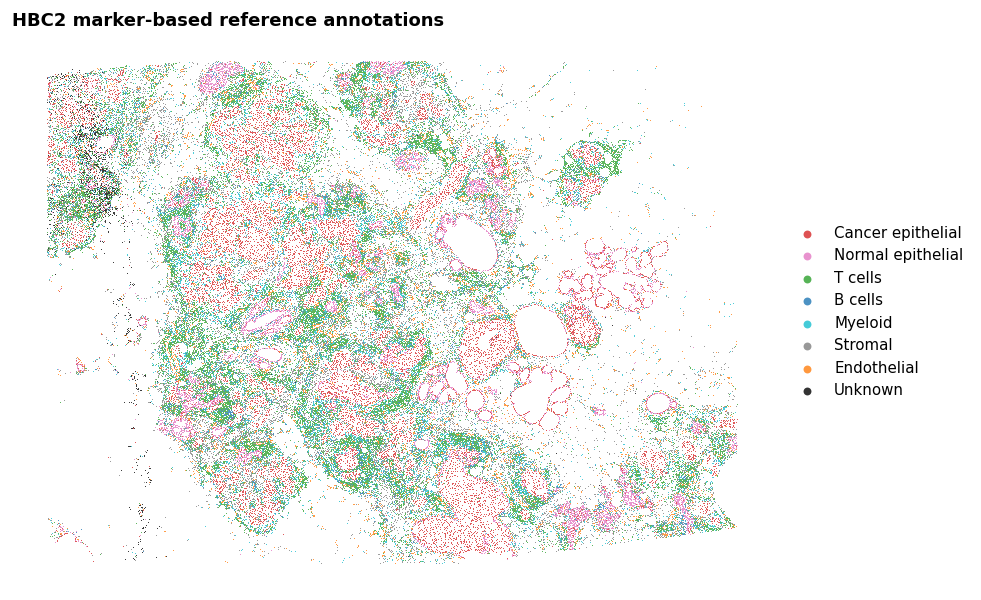

In [3]:
cells, coordinate_shape = load_cell_coordinates(
    ANNOTATION_PATH,
    coordinate_cache=COORDINATE_CACHE,
    mask_path=MASK_PATH,
)
counts = cells["cell_type"].value_counts().reindex(CELL_TYPES).dropna().astype(int)
display(counts.rename_axis("Cell type").rename("Cells").to_frame())

fig, ax = plt.subplots(figsize=(8.0, 5.4))
for cell_type in CELL_TYPES:
    subset = cells.loc[cells["cell_type"].eq(cell_type)]
    if subset.empty:
        continue
    ax.scatter(
        subset["x"], subset["y"], s=0.35, linewidths=0,
        color=CELL_COLORS[cell_type], label=DISPLAY_LABELS[cell_type], rasterized=True,
    )
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("HBC2 marker-based reference annotations", loc="left", fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), markerscale=8)
plt.tight_layout()
plt.show()

## 2. Query phenotype-associated regions from H&E

The three cached maps are source-defined continuous query scores. PhenoMap was trained on HBC1, KEEP is zero-shot, and PathPT tunes only its prompt on the HBC1 support image. HBC2 contributes H&E pixels alone. All panels use the same coordinate frame and the native probability range; higher values indicate stronger phenotype-associated signal.

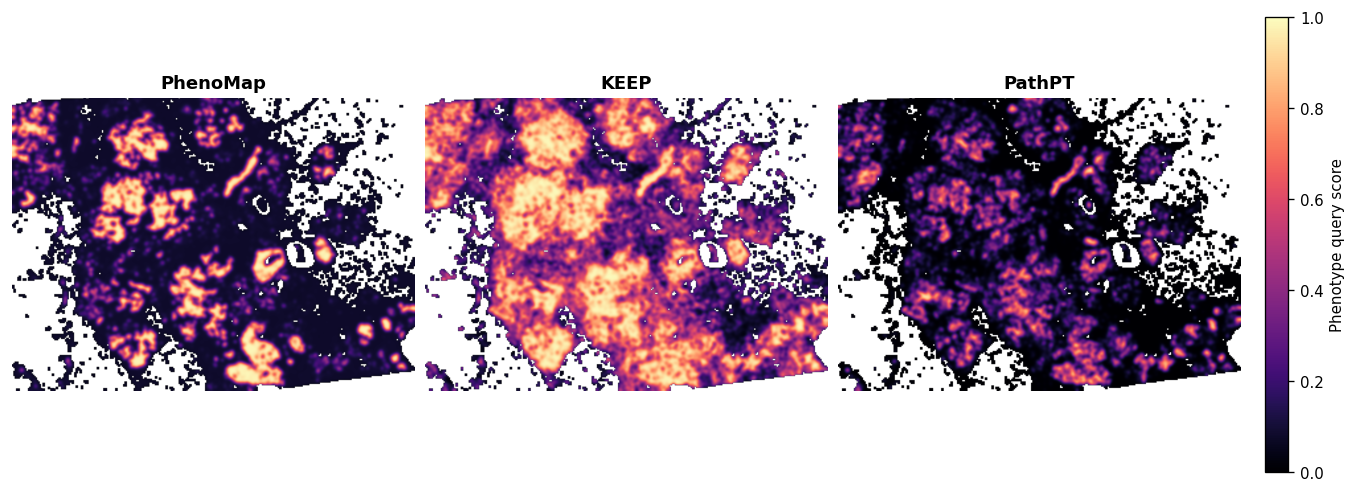

In [4]:
score_maps = {method: np.load(path, mmap_mode="r") for method, path in MAIN_SCORE_PATHS.items()}
fig, axes = plt.subplots(1, 3, figsize=(11.2, 4.0), constrained_layout=True)
for ax, method in zip(axes, METHODS):
    image = plot_query_score_map(score_maps[method][::4, ::4], ax=ax, title=method)
colorbar = fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02)
colorbar.set_label("Phenotype query score")
plt.show()

## 3. Characterize top-scoring queried cells

Each score map is sampled at the same HBC2 cell centers. The stacked bars show the measured-expression reference composition among each method's top 5% scores; the reference classes remain evaluation-only.

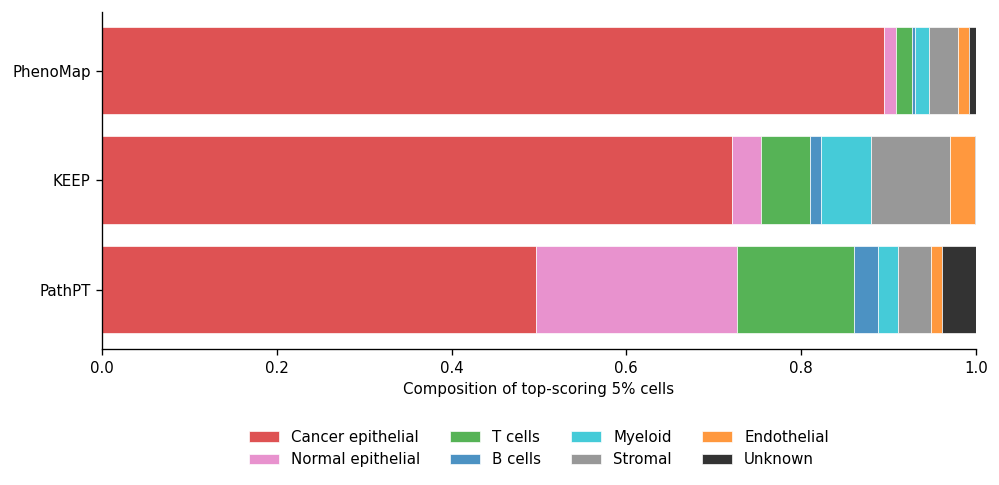

Percent,Cancer epithelial,Normal epithelial,T cells,B cells,Myeloid,Stromal,Endothelial,Unknown
PhenoMap,89.5,1.4,1.8,0.3,1.7,3.2,1.3,0.8
KEEP,72.1,3.3,5.6,1.2,5.8,8.9,2.9,0.0
PathPT,49.7,22.9,13.5,2.7,2.3,3.8,1.3,3.8


In [5]:
main_cells = sample_score_maps(cells, MAIN_SCORE_PATHS, coordinate_shape)
composition = top_fraction_composition(main_cells, METHODS, fraction=0.05)
composition_matrix = (
    composition.pivot(index="method", columns="cell_type", values="fraction")
    .reindex(index=METHODS, columns=CELL_TYPES).fillna(0)
)

fig, ax = plt.subplots(figsize=(8.4, 4.2))
left = np.zeros(len(METHODS))
for cell_type in CELL_TYPES:
    values = composition_matrix[cell_type].to_numpy()
    ax.barh(
        METHODS, values, left=left, color=CELL_COLORS[cell_type],
        edgecolor="white", linewidth=0.4, label=DISPLAY_LABELS[cell_type],
    )
    left += values
ax.set_xlim(0, 1)
ax.set_xlabel("Composition of top-scoring 5% cells")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=4)
plt.tight_layout()
plt.show()

display(
    (100 * composition_matrix).round(1)
    .rename(columns=DISPLAY_LABELS)
    .rename_axis(index=None, columns="Percent")
)

## 4. Evaluate cancer-region localization

Cancer epithelial cells are the positive proxy and every other annotated cell is negative. ROC AUC and average precision are recomputed from the continuous scores without choosing a target-derived threshold.

,Method,Cells,Positive,ROC AUC,Average precision
0,PhenoMap,86000,12679,0.887,0.720
1,KEEP,86000,12679,0.828,0.552
2,PathPT,86000,12679,0.787,0.383


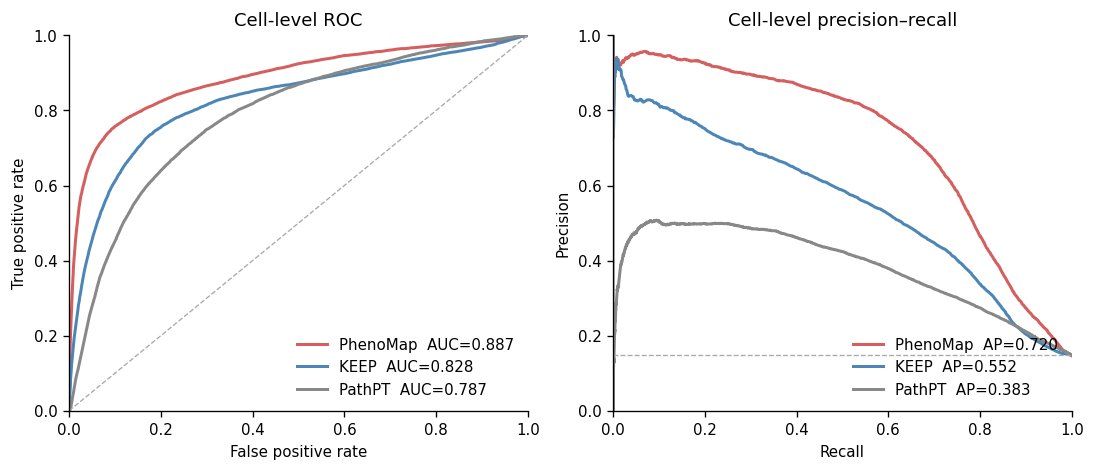

In [6]:
localization, curves = binary_query_performance(main_cells, METHODS)
display(
    localization[["method", "n_cells", "n_positive", "roc_auc", "average_precision"]]
    .round({"roc_auc": 3, "average_precision": 3})
    .rename(columns={
        "method": "Method", "n_cells": "Cells", "n_positive": "Positive",
        "roc_auc": "ROC AUC", "average_precision": "Average precision",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))
plot_binary_query_curves(localization, curves, METHODS, METHOD_COLORS, axes=axes)
plt.tight_layout()
plt.show()

## 5. Compare morphology queries with molecular PR scores

The molecular HBC2 PR score is computed from measured Xenium expression with the Step 2 procedure and oriented by a frozen HBC1-derived molecular anchor. It is never supplied to H&E inference. The final cached score is loaded when available; otherwise Step 2 is run and the source-only orientation is saved.

In [7]:
def ensure_molecular_reference():
    if MOLECULAR_PR_SCORES.exists():
        return MOLECULAR_PR_SCORES, True

    raw_path = MOLECULAR_PR_SCORES.with_name("molecular_pr_raw.parquet")
    runtime_config = OUTPUT_DIR / "hbc2_molecular_pr.yaml"
    config = yaml.safe_load((REPO_ROOT / "step2" / "configs" / "template.yaml").read_text())
    config["data"].update({
        "spatial_expression": str(tutorial_data.require("hbc2.measured_expression")),
        "mask": str(tutorial_data.require("hbc2.nucleus_mask")),
        "spot_diameter_txt": str(tutorial_data.require("hbc1.spot_diameter")),
        "bulk_expression": str(tutorial_data.require("cohorts.tcga_expression")),
        "clinical": str(tutorial_data.require("cohorts.tcga_clinical")),
        "roi": {"x_min": 17000, "x_max": 35000, "y_min": 0, "y_max": 12500},
    })
    config["phenotype"].update({"task": "cox", "time_col": "OS.time", "event_col": "OS.event"})
    config["training"]["device"] = os.environ.get("PHENOMAP_DEVICE", "cuda:0")
    config["output"].update({
        "dir": str(raw_path.parent), "score_file": raw_path.name,
        "checkpoint_file": "molecular_pr_model.pt", "score_column": "phenotype_score",
    })
    config["output"]["orientation"]["enabled"] = False
    raw_path.parent.mkdir(parents=True, exist_ok=True)
    runtime_config.write_text(yaml.safe_dump(config, sort_keys=False))
    run_checked([sys.executable, "step2/scripts/train.py", "--config", str(runtime_config)])

    raw = pd.read_parquet(raw_path).iloc[:, 0]
    oriented, diagnostics = orient_molecular_scores_from_source(
        tutorial_data.require("hbc1.measured_expression"),
        tutorial_data.require("hbc1.phenotype_scores"),
        tutorial_data.require("hbc2.measured_expression"),
        raw,
    )
    oriented.rename("molecular_pr").to_frame().to_parquet(MOLECULAR_PR_SCORES)
    return MOLECULAR_PR_SCORES, False


molecular_path, molecular_cached = ensure_molecular_reference()
molecular_table = pd.read_parquet(molecular_path)
numeric_scores = molecular_table.select_dtypes(include="number")
if numeric_scores.empty:
    raise ValueError("hbc2.molecular_pr_scores must contain a numeric score column.")
molecular = numeric_scores.iloc[:, -1].rename("molecular_pr")
molecular.index = molecular.index.astype(str)

concordance_cells = sample_score_maps(cells, CONCORDANCE_SCORE_PATHS, coordinate_shape)
concordance_cells = concordance_cells.join(molecular, how="inner").dropna()
print(f"Molecular PR cache reused: {molecular_cached}; matched cells: {len(concordance_cells):,}")


Molecular PR cache reused: True; matched cells: 86,000


### Molecular PR spatial map

The map uses the same HBC2 cell coordinates and orientation as the morphology panels.

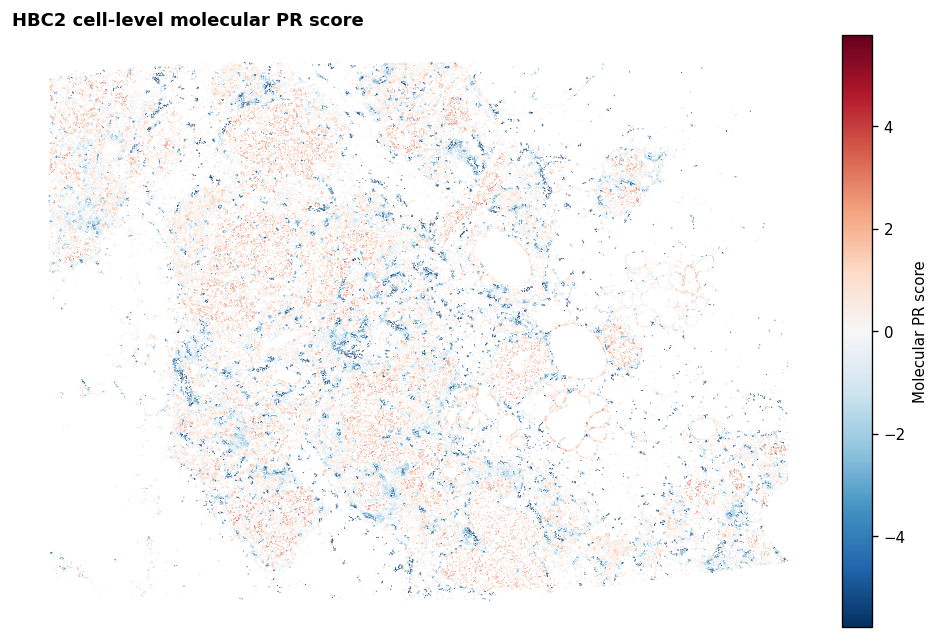

In [8]:
spatial = concordance_cells.sort_values("molecular_pr", key=lambda values: values.abs())
vmax = float(spatial["molecular_pr"].abs().quantile(0.98))
fig, ax = plt.subplots(figsize=(8.0, 5.4))
points = ax.scatter(
    spatial["x"], spatial["y"], c=spatial["molecular_pr"], cmap="RdBu_r",
    vmin=-vmax, vmax=vmax, s=0.4, linewidths=0, rasterized=True,
)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("HBC2 cell-level molecular PR score", loc="left", fontweight="bold")
colorbar = fig.colorbar(points, ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("Molecular PR score")
plt.tight_layout()
plt.show()

### Spatial concordance

Cells are assigned to 1,024×1,024-pixel blocks. S3b correlates block-median molecular and morphology scores with Spearman's rho. S3c reports matched-cell Pearson correlation, with uncertainty obtained by resampling whole blocks. S3d retains only blocks in the highest and lowest molecular-PR quintiles and evaluates their separation by ROC AUC. Every interval uses 2,000 spatial-block bootstrap resamples.

Bootstrap cache reused: True; spatial blocks: 747; resamples: 2,000


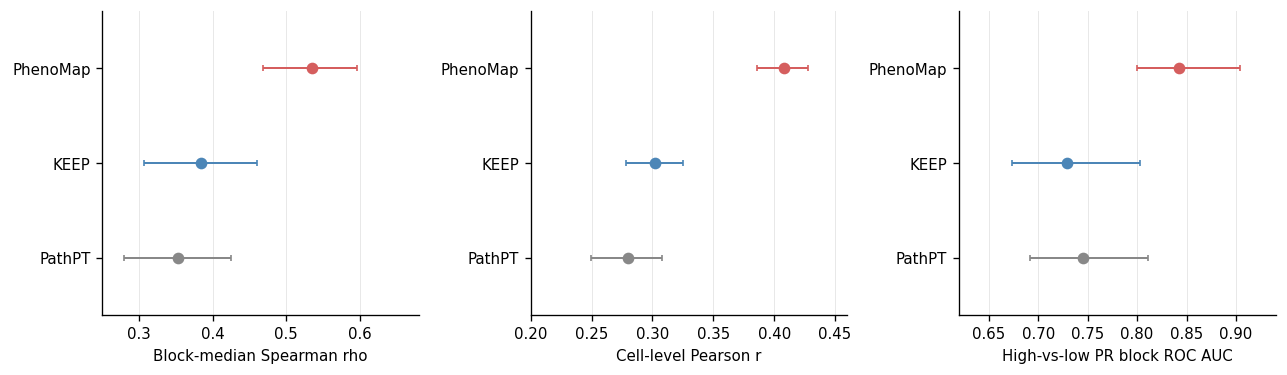

,Block Spearman,Cell Pearson,Extreme-block AUC
PhenoMap,0.535,0.408,0.843
KEEP,0.384,0.302,0.730
PathPT,0.353,0.280,0.745


In [9]:
BLOCK_SIZE = 1024
N_BOOTSTRAP = 2000
BOOTSTRAP_CACHE = TUTORIAL_DIR / "hbc2_spatial_block_bootstrap.csv"
blocks = aggregate_spatial_blocks(
    concordance_cells, ["molecular_pr", *METHODS], block_size=BLOCK_SIZE
)

required_metrics = {"block_spearman", "cell_pearson", "extreme_quintile_auc"}
if BOOTSTRAP_CACHE.exists():
    concordance = pd.read_csv(BOOTSTRAP_CACHE)
    cache_valid = (
        "resampling_scheme" in concordance
        and set(concordance["method"]) == set(METHODS)
        and set(concordance["metric"]) == required_metrics
        and concordance["block_size"].eq(BLOCK_SIZE).all()
        and concordance["n_bootstrap"].eq(N_BOOTSTRAP).all()
        and concordance["resampling_scheme"].eq("paired_spatial_blocks_v1").all()
    )
else:
    cache_valid = False

if not cache_valid:
    concordance = spatial_block_bootstrap(
        concordance_cells, blocks, METHODS,
        molecular_col="molecular_pr", block_size=BLOCK_SIZE,
        n_bootstrap=N_BOOTSTRAP, seed=42,
    )
    concordance.to_csv(BOOTSTRAP_CACHE, index=False)

print(
    f"Bootstrap cache reused: {cache_valid}; spatial blocks: {len(blocks):,}; "
    f"resamples: {N_BOOTSTRAP:,}"
)

metric_specs = [
    ("block_spearman", "Block-median Spearman rho", (0.25, 0.68), 0.0),
    ("cell_pearson", "Cell-level Pearson r", (0.20, 0.46), 0.0),
    ("extreme_quintile_auc", "High-vs-low PR block ROC AUC", (0.62, 0.94), 0.5),
]
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.2))
plot_concordance_intervals(concordance, METHODS, METHOD_COLORS, metric_specs, axes=axes)
plt.tight_layout()
plt.show()

display(
    concordance.pivot(index="method", columns="metric", values="estimate")
    .loc[METHODS, [item[0] for item in metric_specs]].round(3)
    .rename(columns={
        "block_spearman": "Block Spearman",
        "cell_pearson": "Cell Pearson",
        "extreme_quintile_auc": "Extreme-block AUC",
    })
    .rename_axis(index=None, columns=None)
)

## 6. Summary

In the independent same-center HBC2 section, the HBC1-trained PhenoMap query concentrates its highest scores in cancer epithelial regions and outperforms the two morphology baselines for cell-level localization. Its agreement with the independently derived molecular PR landscape is also strongest at both spatial-block and cell levels. Target molecular measurements and labels remain isolated from morphology-model training and inference.

In [10]:
expected = {
    "PhenoMap": (0.887, 0.720),
    "KEEP": (0.828, 0.552),
    "PathPT": (0.787, 0.383),
}
observed = localization.set_index("method")
for method, (expected_auc, expected_ap) in expected.items():
    assert abs(observed.loc[method, "roc_auc"] - expected_auc) < 0.01
    assert abs(observed.loc[method, "average_precision"] - expected_ap) < 0.01
assert len(main_cells) == len(main_cells.index.unique())
assert len(concordance_cells) == len(concordance_cells.index.unique())
assert set(concordance["metric"]) == required_metrics
assert concordance["n_spatial_blocks"].eq(len(blocks)).all()
assert concordance["n_bootstrap"].eq(2000).all()
print("Tutorial checks passed: score direction, matching, metrics and spatial bootstrap definitions.")

Tutorial checks passed: score direction, matching, metrics and spatial bootstrap definitions.
